In [38]:
import geopandas as gpd
import pandas as pd
import numpy as np  

In [4]:
poly = gpd.read_file('data\mine-comm\global_mining_land_use_comm.gpkg')

In [5]:
poly.head()

,area,admin,adm0_a3,row.id,list_of_commodities,geometry
0,0.038096,New Zealand,NZL,1,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250..."
1,0.114247,New Zealand,NZL,2,"Ilmenite,Rutile,Zircon,Heavy Mineral Sands,Gol...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290..."
2,0.125528,New Zealand,NZL,3,"Molybdenum,Tin,Silver,Gold","MULTIPOLYGON (((170.87480 -42.85890, 170.87220..."
3,0.288590,New Zealand,NZL,4,Coal,"MULTIPOLYGON (((168.00960 -45.95730, 168.00900..."
4,0.349819,New Zealand,NZL,5,Coal,"MULTIPOLYGON (((167.88650 -45.89680, 167.88620..."


In [6]:
poly.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 81562 entries, 0 to 81561
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   area                 81562 non-null  float64 
 1   admin                81562 non-null  object  
 2   adm0_a3              81562 non-null  object  
 3   row.id               81562 non-null  int64   
 4   list_of_commodities  58171 non-null  object  
 5   geometry             81562 non-null  geometry
dtypes: float64(1), geometry(1), int64(1), object(3)
memory usage: 3.7+ MB


In [3]:
mines = gpd.read_file('data\mine-comm\global_mining_land_use_comm.gpkg')

mines.head()

,area,admin,adm0_a3,row.id,geometry
0,0.038096,New Zealand,NZL,1,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250..."
1,0.114247,New Zealand,NZL,2,"MULTIPOLYGON (((171.28440 -42.43580, 171.28290..."
2,0.125528,New Zealand,NZL,3,"MULTIPOLYGON (((170.87480 -42.85890, 170.87220..."
3,0.288590,New Zealand,NZL,4,"MULTIPOLYGON (((168.00960 -45.95730, 168.00900..."
4,0.349819,New Zealand,NZL,5,"MULTIPOLYGON (((167.88650 -45.89680, 167.88620..."


In [4]:
mines.shape

(81562, 5)

C:\Users\admin\AppData\Local\Temp\ipykernel_127804\1690256767.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mines.geometry.centroid.plot()


<Axes: >

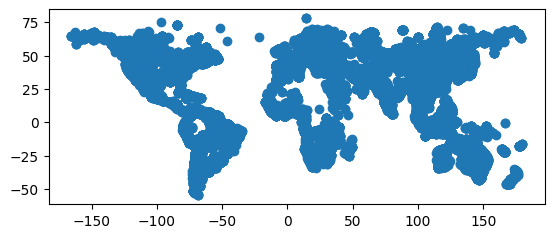

In [5]:
mines.geometry.centroid.plot()

count    81562.000000
mean     40781.500000
std      23545.065665
min          1.000000
25%      20391.250000
50%      40781.500000
75%      61171.750000
max      81562.000000
Name: row.id, dtype: float64

In [20]:
com = pd.read_csv('data\open_mine_db_Jasansky_2023\data\commodities.csv')

In [11]:
com.head()

,id,facility_id,year,material,commodity,value_tonnes,grade_ppm,recovery_rate,yield_ppm,amount_sold_tonnes,metal_payable_tonnes,mine_processing,reporting_period,source_id,comment,id_minerals
0,1,COM00001.00,2013,O.bulk,Me.Ag,37.403,23.01,0.001889,NaN,NaN,NaN,NaN,NaN,det_2964,NaN,2.0
1,2,COM00001.00,2013,O.bulk,Me.Au,3.284,2.02,0.245074,NaN,NaN,NaN,NaN,NaN,det_2964,NaN,2.0
2,3,COM00001.00,2013,O.bulk,Me.Cu,30072.342,18500.00,0.000000,NaN,NaN,NaN,NaN,NaN,det_2964,NaN,2.0
3,4,COM00001.00,2013,O.bulk,Me.Zn,61932.769,38100.00,0.000000,NaN,NaN,NaN,NaN,NaN,det_2964,NaN,2.0
4,5,COM00001.00,2014,O.bulk,Me.Ag,31.209,21.48,0.002167,NaN,NaN,NaN,NaN,NaN,det_2965,NaN,4.0


In [21]:
com.commodity.value_counts()

commodity
Me.Au        2638
Me.Cu        2005
Me.Ag        1443
Me.Zn         848
Me.Pb         623
Me.Ni         498
Oth.cuca      292
Me.Mo         270
Me.Fe         231
Me.Co         107
Me.pgm         64
Nm.dia         59
Me.Pt          57
Me.U3O8        51
Me.Pd          49
Me.Rh          34
Me.Mn          30
Me.Al2O3       25
Me.Ir          25
Me.Ru          25
Me.Sn          19
Me.Nb           8
Me.Te           7
Me.Li2O         5
M.flu           5
Me.Sb           3
Me.Na_nec       2
Nm.PO           2
Me.Ta2O5        1
Name: count, dtype: int64

In [13]:
com.year.value_counts().sort_index(ascending=False)

year
2020     50
2019    401
2018    661
2017    675
2016    650
2015    655
2014    650
2013    666
2012    666
2011    597
2010    546
2009    505
2008    492
2007    459
2006    375
2005    325
2004    254
2003    246
2002    224
2001    202
2000    124
1999      2
1998      1
Name: count, dtype: int64

In [25]:
com.year.describe()

count    9426.000000
mean     2011.453745
std         5.022816
min      1998.000000
25%      2008.000000
50%      2012.000000
75%      2016.000000
max      2020.000000
Name: year, dtype: float64

In [26]:
share = (com.groupby(['facility_id', 'year', 'commodity' ])
              .agg({'value_tonnes': 'sum'})
              .rename(columns={'value_tonnes': 'value_tonnes_com'})
              .reset_index())



share['value_tonnes_total'] = share.groupby(['facility_id', 'year'])['value_tonnes_com'].transform('sum')
share['share'] = share['value_tonnes_com'] / share['value_tonnes_total']



In [186]:
share_clean = share[share['value_tonnes_total']>0]

In [187]:
mean_com = share_clean.groupby(['commodity','year'])['share'].agg(['mean', 'std']).reset_index()


<Axes: xlabel='year', ylabel='mean'>

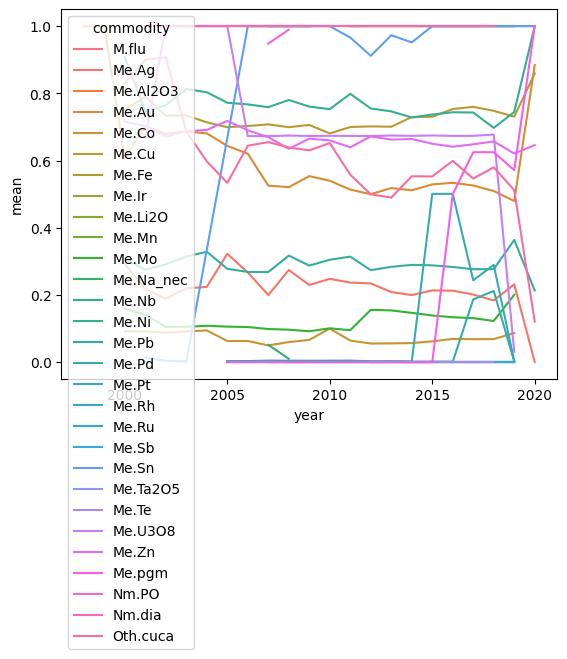

In [198]:
import seaborn as sns

sns.lineplot(data=mean_com, x='year', y='mean', hue='commodity')

In [189]:
share_heat = mean_com.pivot(index='commodity', columns='year', values='mean')

In [190]:
mean_com['std'].fillna(0, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_144440\3144723247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mean_com['std'].fillna(0, inplace=True)


In [191]:
mean_com['cv'] = mean_com['std'] / mean_com['mean']

In [192]:
cv_heat = mean_com.pivot(index='commodity', columns='year', values='cv')

In [193]:
cv_heat.head()

year,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
commodity,,,,,,,,,,,,,,,,,,,,,
M.flu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Me.Ag,NaN,NaN,1.427068,1.705451,1.884952,1.726736,1.680934,1.353710,1.536137,1.870766,...,1.627039,1.615800,1.734112,1.814039,1.694371,1.707572,1.758273,1.874855,1.620645,0.000000
Me.Al2O3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
Me.Au,0.0,0.0,0.787180,0.634736,0.673729,0.661635,0.670996,0.727686,0.766600,0.932571,...,0.941446,0.957435,0.929452,0.949085,0.911111,0.904504,0.917559,0.949935,0.999786,0.368116
Me.Co,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.734918,0.794419,0.900540,...,0.599394,0.680831,0.543565,0.538897,0.540986,0.522008,0.666074,0.717621,0.661966,NaN


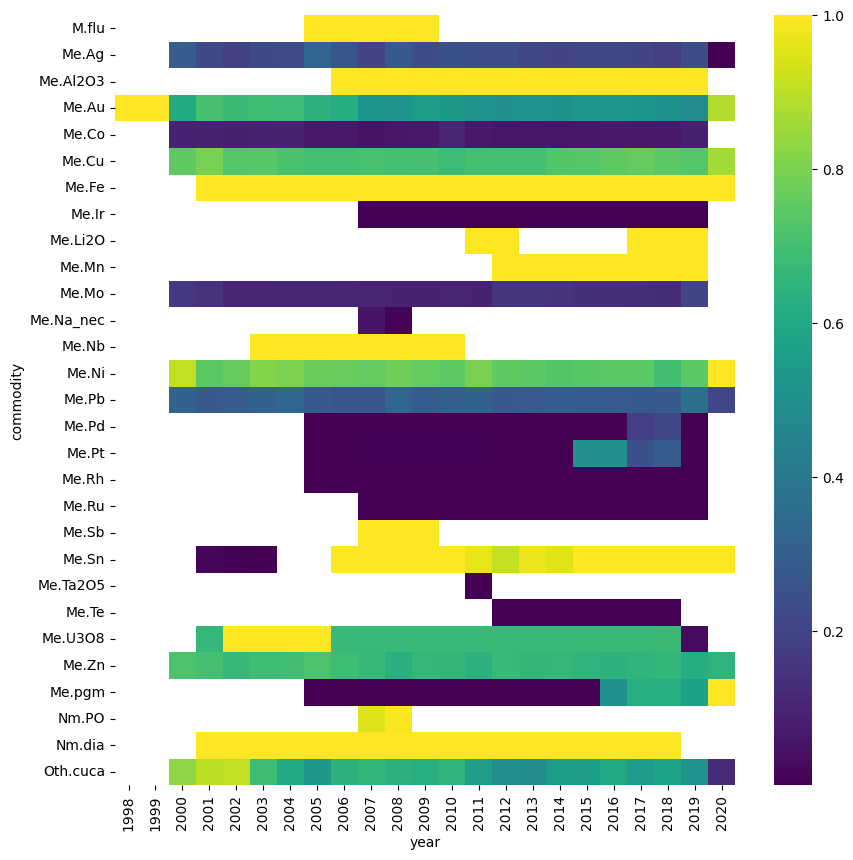

In [194]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(share_heat, cmap='viridis')
plt.savefig('fig/share_heat.png')

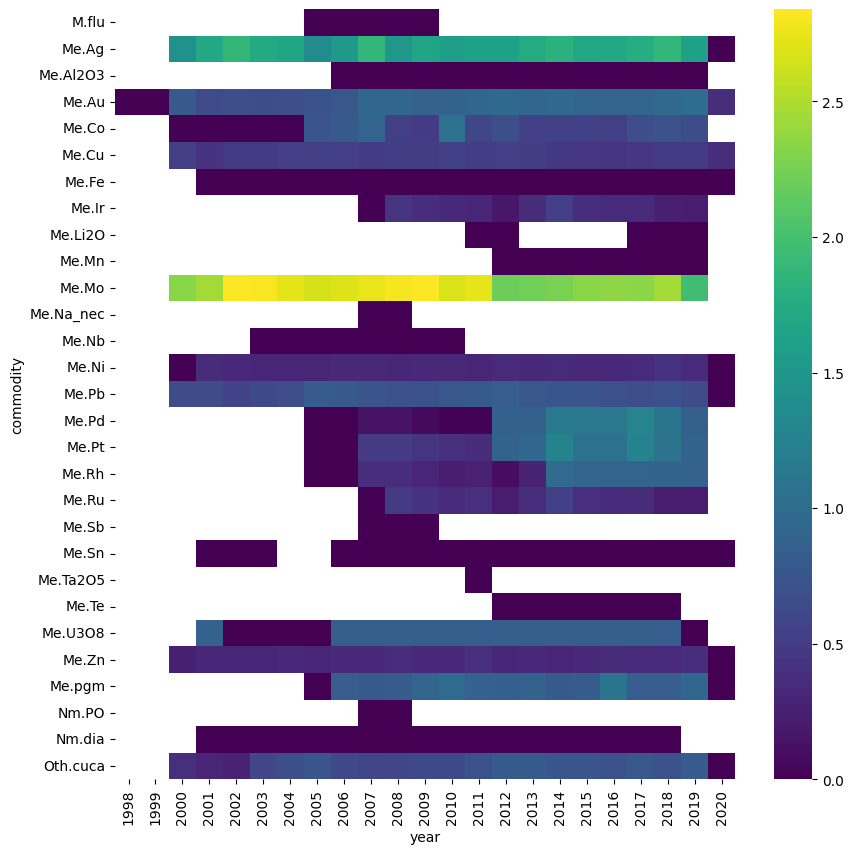

In [199]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(cv_heat, cmap='viridis')

plt.savefig('fig/cv_heat.png')

In [89]:
mean_com.head()

,commodity,year,mean,std,cv
0,M.flu,2005,1.0,0.0,0.0
1,M.flu,2006,1.0,0.0,0.0
2,M.flu,2007,1.0,0.0,0.0
3,M.flu,2008,1.0,0.0,0.0
4,M.flu,2009,1.0,0.0,0.0


C:\Users\admin\AppData\Local\Temp\ipykernel_144440\229845973.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=mean_com, x='cv', hue='year', ax=ax, legend=True, c='YlGnBu')


<Axes: xlabel='cv', ylabel='Density'>

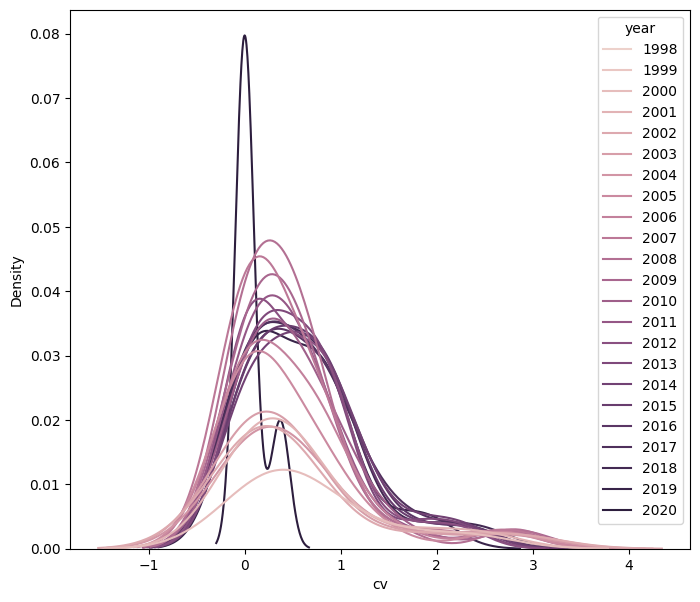

In [200]:
import seaborn as sns
import matplotlib.pyplot as plt

# Your code here
fig, ax = plt.subplots(figsize=(8, 7))
# Create the plot
sns.kdeplot(data=mean_com, x='cv', hue='year', ax=ax, legend=True, c='YlGnBu')








<Axes: ylabel='Frequency'>

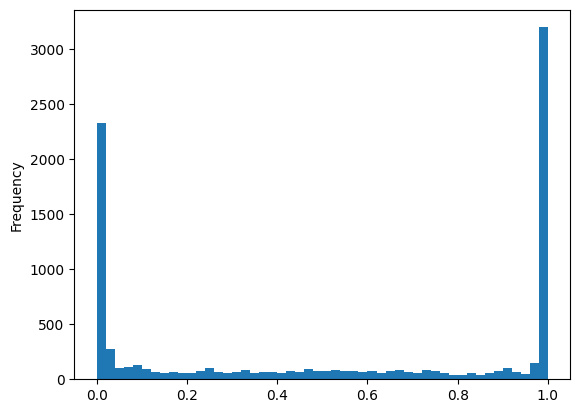

In [122]:
share.share.plot.hist(bins=50)

<Axes: ylabel='Frequency'>

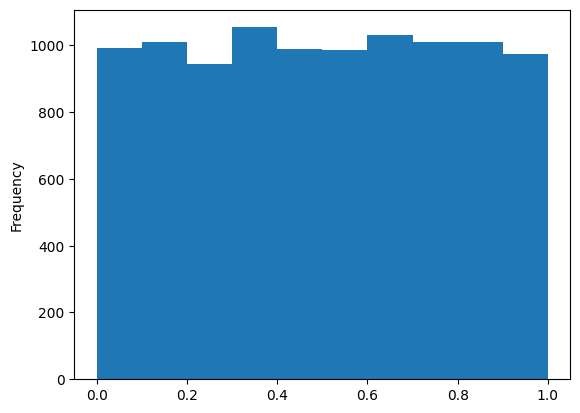

In [128]:
from scipy.stats import uniform

pd.Series(uniform.rvs(size=10000)).plot.hist()

In [243]:
from scipy.stats import bootstrap


def commodity_bootstrap(data, stat=np.mean, con_level=0.90, **kwargs): 
    data = np.array(data)
    # case not enough data to bootstrap
    if len(data) < 2:
        conf = ((0, 1), uniform.rvs(size=10000))

    #case all data is the same
    elif len(np.unique(data)) == 1:
        share = float(np.unique(data))
        conf = ((share, share), [share for i in range (10000)])        

    else:
        boot = bootstrap((data,), statistic=stat, confidence_level=con_level)
        conf = (boot.confidence_interval, boot.bootstrap_distribution)
    
    return conf


In [236]:
share.columns

Index(['facility_id', 'year', 'commodity', 'value_tonnes_com',
       'value_tonnes_total', 'share'],
      dtype='object')

In [244]:

share_boot = (share_clean.groupby(['commodity','year'])['share']
         .apply(commodity_bootstrap)
         .apply(pd.Series)
         .rename(columns={0: 'confidence_interval', 1: 'bootstrap_distribution'})
         .assign(conf_low = lambda x: x['confidence_interval'].apply(lambda y: y[0]), conf_high = lambda x: x['confidence_interval'].apply(lambda y: y[1]))
         .reset_index())



C:\Users\admin\AppData\Local\Temp\ipykernel_144440\176777997.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  share = float(np.unique(data))


In [246]:
share_boot.confidence_interval.unique()

array([(0, 1),
       ConfidenceInterval(low=0.1550259848938136, high=0.4787421363573613),
       ConfidenceInterval(low=0.11037572360868524, high=0.36328634099318163),
       ConfidenceInterval(low=0.09990472284264995, high=0.32245165576495716),
       ConfidenceInterval(low=0.11877755096253799, high=0.35451458392649643),
       ConfidenceInterval(low=0.12718259657240918, high=0.35845541629478117),
       ConfidenceInterval(low=0.21565982797694155, high=0.4507756385533243),
       ConfidenceInterval(low=0.18008443175485356, high=0.3783305349844972),
       ConfidenceInterval(low=0.1348437170385987, high=0.2855207093550597),
       ConfidenceInterval(low=0.20365976305248948, high=0.3586806921210776),
       ConfidenceInterval(low=0.1634528107184153, high=0.30948830503709124),
       ConfidenceInterval(low=0.18516700453385387, high=0.32337942525506447),
       ConfidenceInterval(low=0.17558790023518595, high=0.3054692836391582),
       ConfidenceInterval(low=0.1783251984530422, high=0.2

In [247]:
share_boot['range'] = share_boot['conf_high'] - share_boot['conf_low']

<Axes: xlabel='year', ylabel='commodity'>

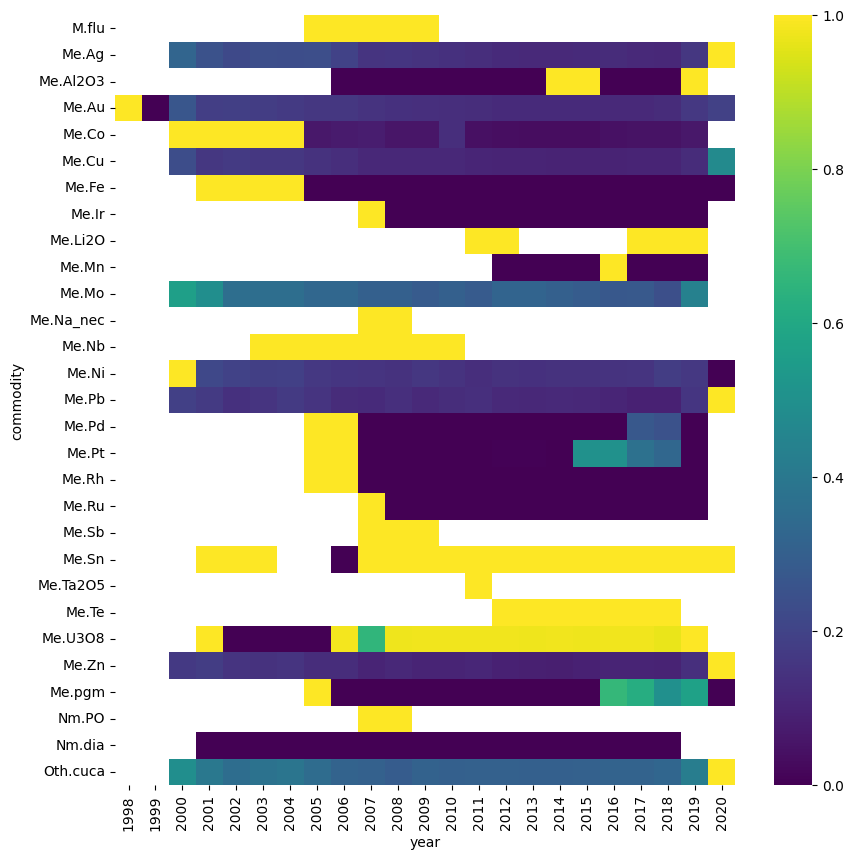

In [248]:
range_heat = share_boot.pivot(index='commodity', columns='year', values='range').astype(float)
plt.figure(figsize=(10, 10))
sns.heatmap(range_heat, cmap='viridis')

In [249]:
conf_2017 = share_boot.query('year == 2017')

In [230]:
coverage = share_clean.groupby(['commodity', 'year'])['facility_id'].count().reset_index()


<Figure size 1000x1000 with 0 Axes>

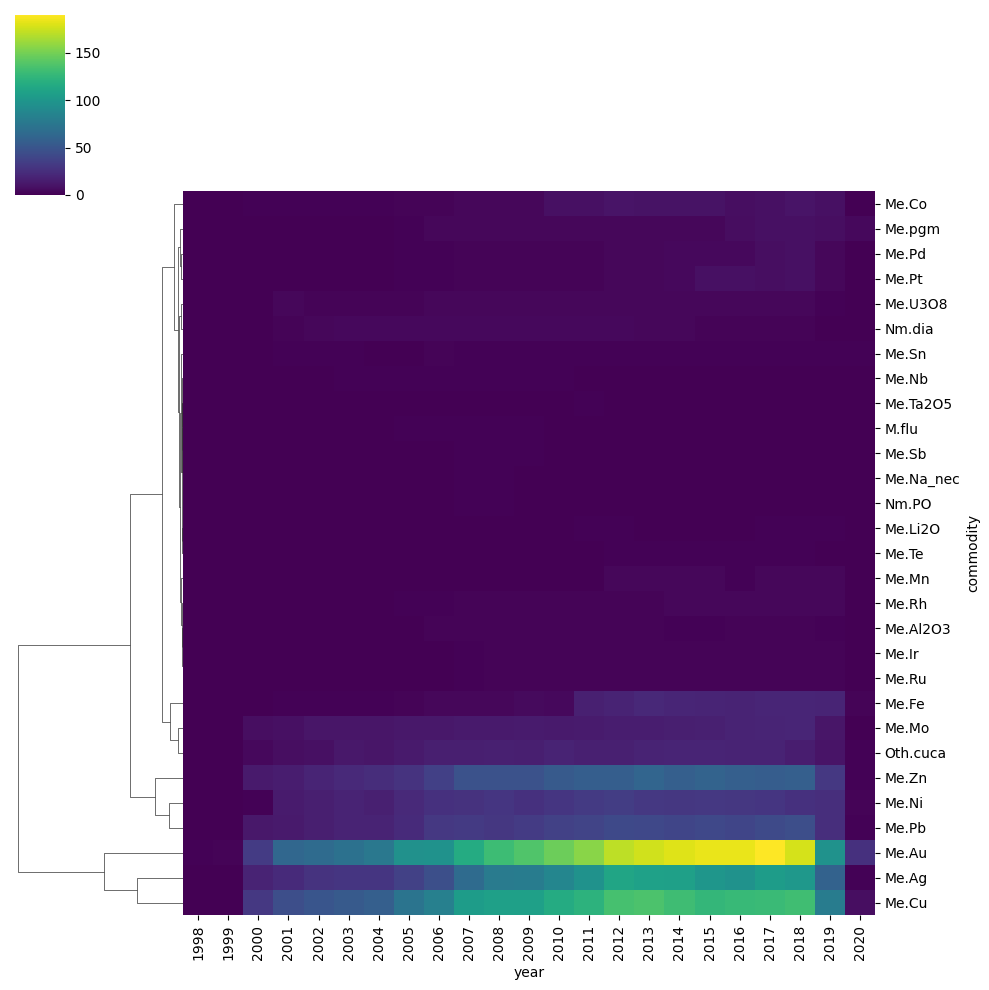

In [250]:
coverage_heat = coverage.pivot(index='commodity', columns='year', values='facility_id')

plt.figure(figsize=(10, 10))
sns.clustermap(coverage_heat.fillna(0), cmap='viridis', col_cluster=False)




In [272]:
share_boot['conf_mean'] = share_boot['bootstrap_distribution'].apply(np.mean)

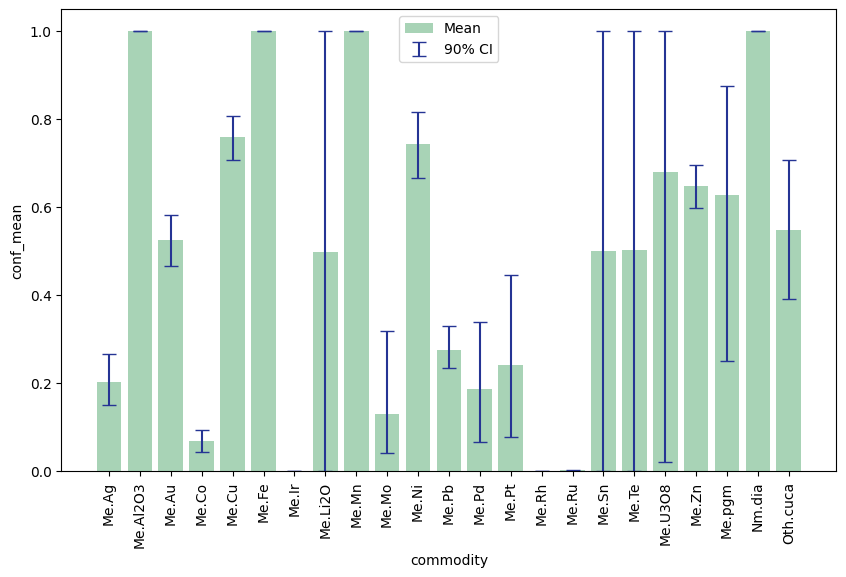

<Figure size 640x480 with 0 Axes>

In [300]:

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=share_boot[share_boot.year==2017], x='commodity', y='conf_mean', ax=ax, color='#a1dab4', label='Mean')
ax.errorbar(x=share_boot[share_boot.year==2017]['commodity'], y=share_boot[share_boot.year==2017]['conf_mean'], 
         yerr=[share_boot[share_boot.year==2017]['conf_mean'] - share_boot[share_boot.year==2017]['conf_low'], 
             share_boot[share_boot.year==2017]['conf_high'] - share_boot[share_boot.year==2017]['conf_mean']], 
         fmt='none', color='#253494', capsize=5, label='90% CI')


plt.xticks(rotation=90)
plt.legend()

plt.show()

plt.savefig('fig/mean_conf.png')


In [303]:
share_boot.head()

,commodity,year,confidence_interval,bootstrap_distribution,conf_low,conf_high,range,conf_mean
0,M.flu,2005,"(0, 1)","[0.9585388059120884, 0.5717160743190546, 0.325...",0.0,1.0,1.0,0.499945
1,M.flu,2006,"(0, 1)","[0.9914965193065334, 0.5122235518125863, 0.235...",0.0,1.0,1.0,0.501197
2,M.flu,2007,"(0, 1)","[0.7619747993830569, 0.413387931896128, 0.6250...",0.0,1.0,1.0,0.502331
3,M.flu,2008,"(0, 1)","[0.7463344468498151, 0.611286114361788, 0.1943...",0.0,1.0,1.0,0.498002
4,M.flu,2009,"(0, 1)","[0.6496898322252934, 0.6389663269613439, 0.363...",0.0,1.0,1.0,0.499739


conf_2017

ids = pd.read_csv('data\open_mine_db_Jasansky_2023\data\commodity_ids.csv')

In [306]:
ids = pd.read_csv('data\open_mine_db_Jasansky_2023\data\material_ids.csv')

In [332]:
com_join = share_boot.merge(ids, left_on='commodity', right_on='material_id', how='left')

In [333]:
com_join.head()

,commodity,year,confidence_interval,bootstrap_distribution,conf_low,conf_high,range,conf_mean,material_id,material_name,material_category,material_category_2,material_id_agg,material_name_agg,materials_contained
0,M.flu,2005,"(0, 1)","[0.9585388059120884, 0.5717160743190546, 0.325...",0.0,1.0,1.0,0.499945,M.flu,Fluorspar,mineral,non-metallic mineral,NaN,NaN,NaN
1,M.flu,2006,"(0, 1)","[0.9914965193065334, 0.5122235518125863, 0.235...",0.0,1.0,1.0,0.501197,M.flu,Fluorspar,mineral,non-metallic mineral,NaN,NaN,NaN
2,M.flu,2007,"(0, 1)","[0.7619747993830569, 0.413387931896128, 0.6250...",0.0,1.0,1.0,0.502331,M.flu,Fluorspar,mineral,non-metallic mineral,NaN,NaN,NaN
3,M.flu,2008,"(0, 1)","[0.7463344468498151, 0.611286114361788, 0.1943...",0.0,1.0,1.0,0.498002,M.flu,Fluorspar,mineral,non-metallic mineral,NaN,NaN,NaN
4,M.flu,2009,"(0, 1)","[0.6496898322252934, 0.6389663269613439, 0.363...",0.0,1.0,1.0,0.499739,M.flu,Fluorspar,mineral,non-metallic mineral,NaN,NaN,NaN


In [334]:
com_join.drop(['material_id_agg', 'material_id', 'material_name_agg', 'materials_contained'], axis=1, inplace=True)

In [335]:
com_join.head(40)

,commodity,year,confidence_interval,bootstrap_distribution,conf_low,conf_high,range,conf_mean,material_name,material_category,material_category_2
0,M.flu,2005,"(0, 1)","[0.9585388059120884, 0.5717160743190546, 0.325...",0.000000,1.000000,1.000000,0.499945,Fluorspar,mineral,non-metallic mineral
1,M.flu,2006,"(0, 1)","[0.9914965193065334, 0.5122235518125863, 0.235...",0.000000,1.000000,1.000000,0.501197,Fluorspar,mineral,non-metallic mineral
2,M.flu,2007,"(0, 1)","[0.7619747993830569, 0.413387931896128, 0.6250...",0.000000,1.000000,1.000000,0.502331,Fluorspar,mineral,non-metallic mineral
3,M.flu,2008,"(0, 1)","[0.7463344468498151, 0.611286114361788, 0.1943...",0.000000,1.000000,1.000000,0.498002,Fluorspar,mineral,non-metallic mineral
4,M.flu,2009,"(0, 1)","[0.6496898322252934, 0.6389663269613439, 0.363...",0.000000,1.000000,1.000000,0.499739,Fluorspar,mineral,non-metallic mineral
5,Me.Ag,2000,"(0.1550259848938136, 0.4787421363573613)","[0.17173880404349512, 0.2551297710926991, 0.29...",0.155026,0.478742,0.323716,0.292155,Silver,commodity,metal
6,Me.Ag,2001,"(0.11037572360868524, 0.36328634099318163)","[0.21002104770515906, 0.17455748921872416, 0.1...",0.110376,0.363286,0.252911,0.217799,Silver,commodity,metal
7,Me.Ag,2002,"(0.09990472284264995, 0.32245165576495716)","[0.23135463044054422, 0.20592227201490623, 0.2...",0.099905,0.322452,0.222547,0.188486,Silver,commodity,metal
8,Me.Ag,2003,"(0.11877755096253799, 0.35451458392649643)","[0.1271070207799978, 0.17716316081735498, 0.15...",0.118778,0.354515,0.235737,0.219915,Silver,commodity,metal
9,Me.Ag,2004,"(0.12718259657240918, 0.35845541629478117)","[0.19716441499408668, 0.25508262480444854, 0.1...",0.127183,0.358455,0.231273,0.224767,Silver,commodity,metal


In [336]:
com_join 

,commodity,year,confidence_interval,bootstrap_distribution,conf_low,conf_high,range,conf_mean,material_name,material_category,material_category_2
0,M.flu,2005,"(0, 1)","[0.9585388059120884, 0.5717160743190546, 0.325...",0.000000,1.000000,1.000000,0.499945,Fluorspar,mineral,non-metallic mineral
1,M.flu,2006,"(0, 1)","[0.9914965193065334, 0.5122235518125863, 0.235...",0.000000,1.000000,1.000000,0.501197,Fluorspar,mineral,non-metallic mineral
2,M.flu,2007,"(0, 1)","[0.7619747993830569, 0.413387931896128, 0.6250...",0.000000,1.000000,1.000000,0.502331,Fluorspar,mineral,non-metallic mineral
3,M.flu,2008,"(0, 1)","[0.7463344468498151, 0.611286114361788, 0.1943...",0.000000,1.000000,1.000000,0.498002,Fluorspar,mineral,non-metallic mineral
4,M.flu,2009,"(0, 1)","[0.6496898322252934, 0.6389663269613439, 0.363...",0.000000,1.000000,1.000000,0.499739,Fluorspar,mineral,non-metallic mineral
...,...,...,...,...,...,...,...,...,...,...,...
401,Oth.cuca,2016,"(0.437808021697216, 0.7537876110730142)","[0.6780285007361747, 0.6996433578936432, 0.709...",0.437808,0.753788,0.315980,0.598681,Copper cathode,other_product,metal product
402,Oth.cuca,2017,"(0.39215175466756097, 0.7062405673054685)","[0.33811418467822574, 0.5361920811585494, 0.43...",0.392152,0.706241,0.314089,0.547177,Copper cathode,other_product,metal product
403,Oth.cuca,2018,"(0.41938951616386, 0.7468304134000019)","[0.6132947373406624, 0.5904006349089718, 0.701...",0.419390,0.746830,0.327441,0.578901,Copper cathode,other_product,metal product
404,Oth.cuca,2019,"(0.32556553885642997, 0.744627128070689)","[0.6716763617994129, 0.5897605159119188, 0.272...",0.325566,0.744627,0.419062,0.512162,Copper cathode,other_product,metal product


In [356]:
slice = com_join[(com_join.range > 0) & (com_join.range < 1)]

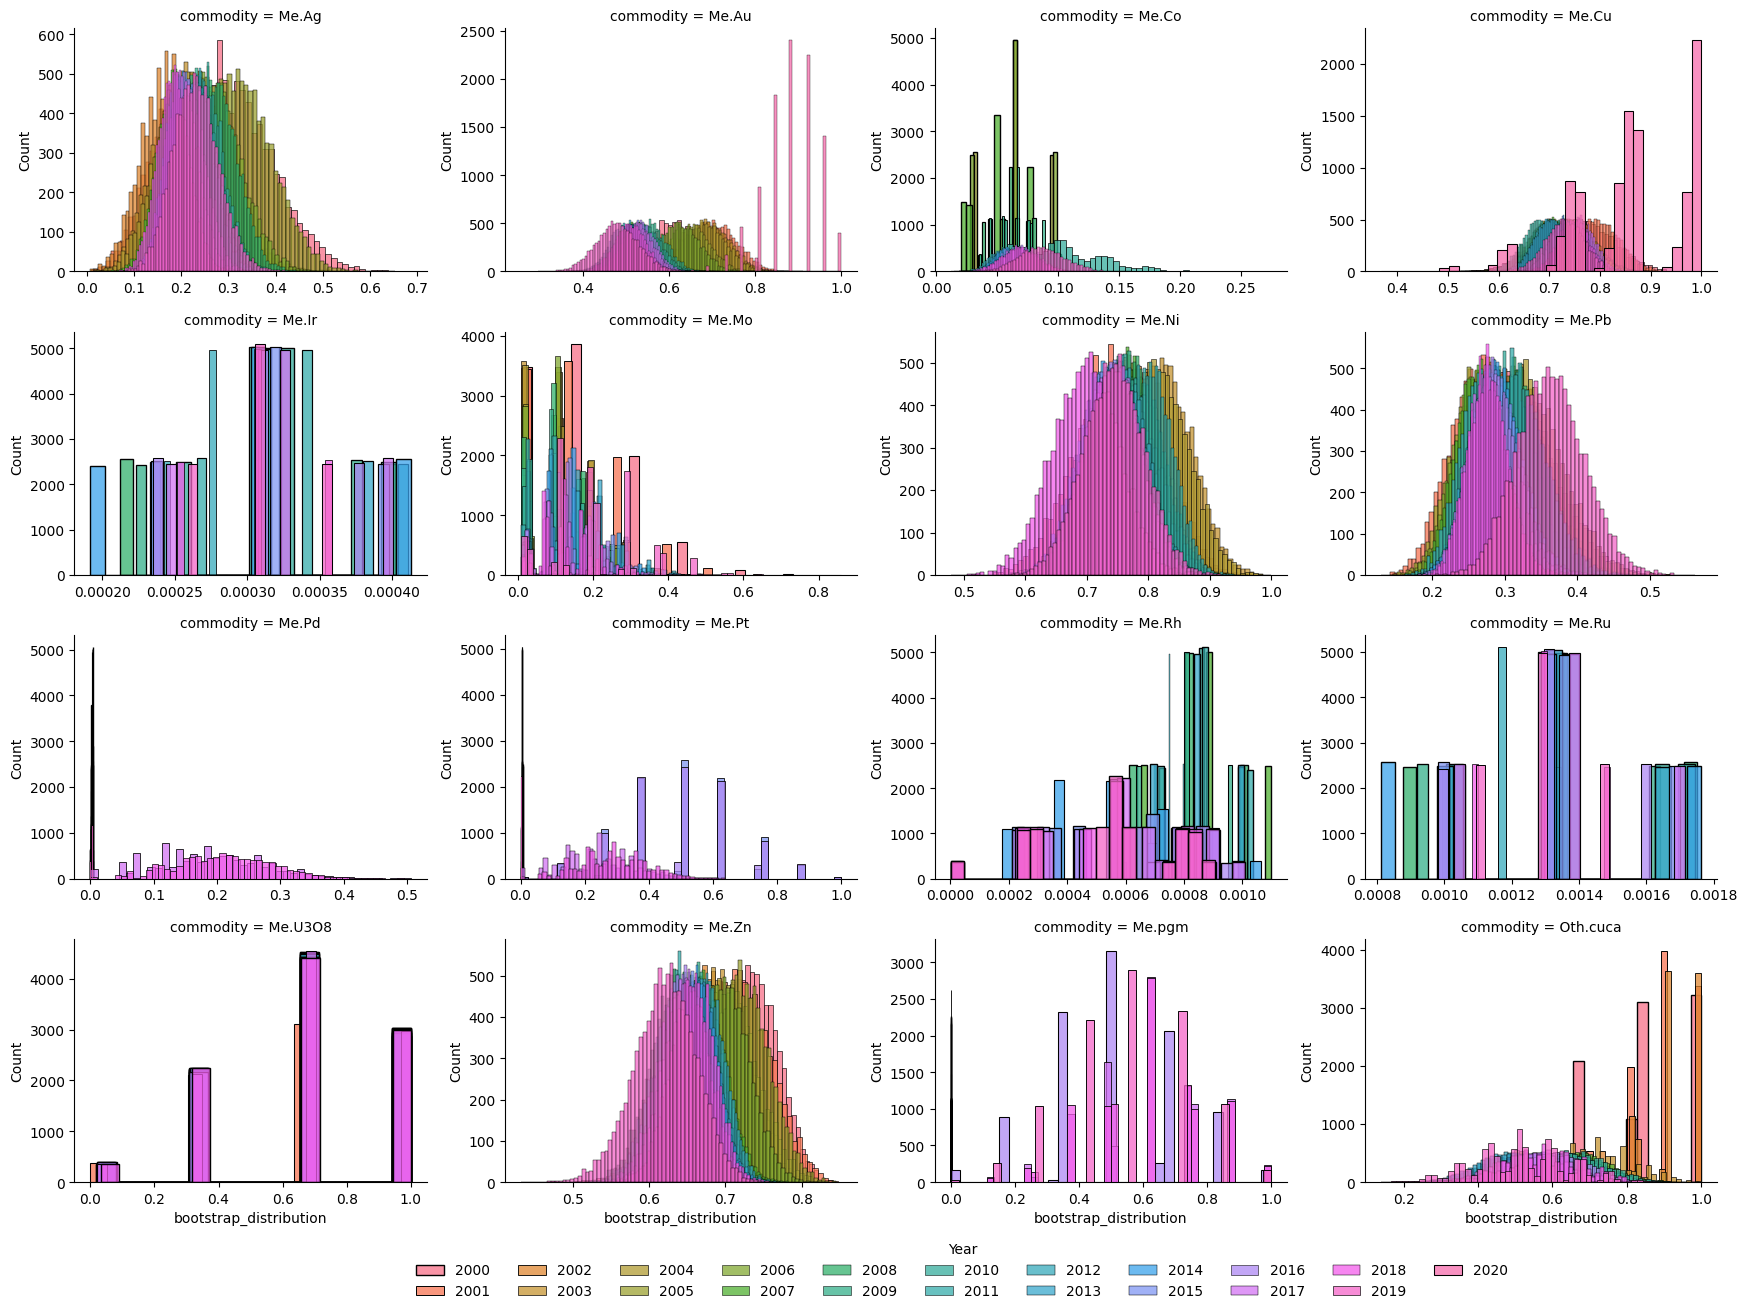

<Figure size 640x480 with 0 Axes>

In [403]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# Define a function to create histograms
def trans(data, **kwargs):
    data = np.array(data)
    for d in data:
        sns.histplot(d, **kwargs)

# Create a FacetGrid
g = sns.FacetGrid(slice, hue='year', col="commodity", col_wrap=4, margin_titles=True, height=3, aspect=1.5, sharex=False, sharey=False)

# Map the custom function to create histograms
g.map(trans, "bootstrap_distribution", multiple="stack")

# Adjust the spacing to place the legend vertically under the facets
plt.subplots_adjust(bottom=0.01)

# Add legend vertically under the facets
g.add_legend(title='Year', loc='upper center', bbox_to_anchor=(0.35, -0.03), ncol=11)

# Show the plot
plt.show()

plt.savefig('fig/com_distrib.png')



Merge Mines and commodities.

In [404]:
poly = gpd.read_file('data\mine-comm\global_mining_land_use_comm.gpkg')

In [407]:
poly.columns

Index(['area', 'admin', 'adm0_a3', 'row.id', 'list_of_commodities',
       'geometry'],
      dtype='object')

In [432]:
def spl(data):
    if data == None:
        return [None]
    else:
        data = data.split(',')
    return data


In [433]:
poly.list_of_commodities

0        [Ilmenite, Rutile, Zircon, Heavy Mineral Sands...
1        [Ilmenite, Rutile, Zircon, Heavy Mineral Sands...
2                          [Molybdenum, Tin, Silver, Gold]
3                                                   [Coal]
4                                                   [Coal]
                               ...                        
81557                                                 None
81558                                                 None
81559                                                 None
81560                                                 None
81561                                                 None
Name: list_of_commodities, Length: 81562, dtype: object

In [434]:
poly['list_of_commodities'] = poly['list_of_commodities'].apply(spl)

AttributeError: 'list' object has no attribute 'split'

In [445]:
poly.set_index('row.id', inplace=True)

In [446]:
poly.head()

,area,admin,adm0_a3,list_of_commodities,geometry,commodity
row.id,,,,,,
1,0.038096,New Zealand,NZL,"[Ilmenite, Rutile, Zircon, Heavy Mineral Sands...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Ilmenite
2,0.114247,New Zealand,NZL,"[Ilmenite, Rutile, Zircon, Heavy Mineral Sands...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290...",Rutile
3,0.125528,New Zealand,NZL,"[Molybdenum, Tin, Silver, Gold]","MULTIPOLYGON (((170.87480 -42.85890, 170.87220...",Zircon
4,0.288590,New Zealand,NZL,[Coal],"MULTIPOLYGON (((168.00960 -45.95730, 168.00900...",Heavy Mineral Sands
5,0.349819,New Zealand,NZL,[Coal],"MULTIPOLYGON (((167.88650 -45.89680, 167.88620...",Gold


In [450]:
join = poly.join(pd.Series(poly['list_of_commodities'].explode()), rsuffix='_com')


In [455]:
from copy import deepcopy
join = deepcopy(join)

In [457]:
join.rename(columns={'list_of_commodities_com': 'commodity'}, inplace=True)

In [453]:
join.drop(['list_of_commodities', 'commodity'], axis=1, inplace=True)

KeyError: "['list_of_commodities', 'commodity'] not found in axis"

In [428]:
poly.head()

,area,admin,adm0_a3,row.id,list_of_commodities,geometry,commodity
0,0.038096,New Zealand,NZL,1,"[Ilmenite, Rutile, Zircon, Heavy Mineral Sands...","MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Ilmenite
1,0.114247,New Zealand,NZL,2,"[Ilmenite, Rutile, Zircon, Heavy Mineral Sands...","MULTIPOLYGON (((171.28440 -42.43580, 171.28290...",Rutile
2,0.125528,New Zealand,NZL,3,"[Molybdenum, Tin, Silver, Gold]","MULTIPOLYGON (((170.87480 -42.85890, 170.87220...",Zircon
3,0.288590,New Zealand,NZL,4,[Coal],"MULTIPOLYGON (((168.00960 -45.95730, 168.00900...",Heavy Mineral Sands
4,0.349819,New Zealand,NZL,5,[Coal],"MULTIPOLYGON (((167.88650 -45.89680, 167.88620...",Gold


In [459]:
com_join.columns

Index(['commodity', 'year', 'confidence_interval', 'bootstrap_distribution',
       'conf_low', 'conf_high', 'range', 'conf_mean', 'material_name',
       'material_category', 'material_category_2'],
      dtype='object')

In [461]:
df = join.merge(com_join, left_on='commodity', right_on='material_name')

In [462]:
df.head()

,area,admin,adm0_a3,geometry,commodity_x,commodity_y,year,confidence_interval,bootstrap_distribution,conf_low,conf_high,range,conf_mean,material_name,material_category,material_category_2
0,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,1998,"(0, 1)","[0.16398703538383563, 0.4411224864552886, 0.67...",0.000000,1.000000,1.000000,0.501348,Gold,commodity,metal
1,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,1999,"(1.0, 1.0)","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.000000,1.000000,0.000000,1.000000,Gold,commodity,metal
2,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,2000,"(0.4661310258571013, 0.7322742761219094)","[0.5554821332737778, 0.6864135012289143, 0.703...",0.466131,0.732274,0.266143,0.606525,Gold,commodity,metal
3,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,2001,"(0.6069201683931131, 0.7884157022534607)","[0.7629827905521726, 0.6357633338641534, 0.728...",0.606920,0.788416,0.181496,0.703804,Gold,commodity,metal
4,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,2002,"(0.5800628747737165, 0.7636785214750301)","[0.6973738319373802, 0.7333998190796847, 0.664...",0.580063,0.763679,0.183616,0.680423,Gold,commodity,metal


In [463]:
df.shape

(3233050, 16)

In [464]:
com.head()

,id,facility_id,year,material,commodity,value_tonnes,grade_ppm,recovery_rate,yield_ppm,amount_sold_tonnes,metal_payable_tonnes,mine_processing,reporting_period,source_id,comment,id_minerals
0,1,COM00001.00,2013,O.bulk,Me.Ag,37.403,23.01,0.001889,NaN,NaN,NaN,NaN,NaN,det_2964,NaN,2.0
1,2,COM00001.00,2013,O.bulk,Me.Au,3.284,2.02,0.245074,NaN,NaN,NaN,NaN,NaN,det_2964,NaN,2.0
2,3,COM00001.00,2013,O.bulk,Me.Cu,30072.342,18500.00,0.000000,NaN,NaN,NaN,NaN,NaN,det_2964,NaN,2.0
3,4,COM00001.00,2013,O.bulk,Me.Zn,61932.769,38100.00,0.000000,NaN,NaN,NaN,NaN,NaN,det_2964,NaN,2.0
4,5,COM00001.00,2014,O.bulk,Me.Ag,31.209,21.48,0.002167,NaN,NaN,NaN,NaN,NaN,det_2965,NaN,4.0


In [465]:
prod = com.groupby(['commodity', 'year']).agg({'value_tonnes': 'sum'}).reset_index()

prod.head()

,commodity,year,value_tonnes
0,M.flu,2005,143086.0
1,M.flu,2006,156692.0
2,M.flu,2007,183199.0
3,M.flu,2008,180854.0
4,M.flu,2009,152934.0


In [470]:
full = df.merge(prod, left_on=['commodity_y', 'year'],right_on=['commodity', 'year'], how='left')

In [471]:
full.head()

,area,admin,adm0_a3,geometry,commodity_x,commodity_y,year,confidence_interval,bootstrap_distribution,conf_low,conf_high,range,conf_mean,material_name,material_category,material_category_2,commodity,value_tonnes
0,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,1998,"(0, 1)","[0.16398703538383563, 0.4411224864552886, 0.67...",0.000000,1.000000,1.000000,0.501348,Gold,commodity,metal,Me.Au,9.949
1,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,1999,"(1.0, 1.0)","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.000000,1.000000,0.000000,1.000000,Gold,commodity,metal,Me.Au,18.810
2,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,2000,"(0.4661310258571013, 0.7322742761219094)","[0.5554821332737778, 0.6864135012289143, 0.703...",0.466131,0.732274,0.266143,0.606525,Gold,commodity,metal,Me.Au,367.252
3,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,2001,"(0.6069201683931131, 0.7884157022534607)","[0.7629827905521726, 0.6357633338641534, 0.728...",0.606920,0.788416,0.181496,0.703804,Gold,commodity,metal,Me.Au,689.507
4,0.038096,New Zealand,NZL,"MULTIPOLYGON (((171.46400 -42.43900, 171.46250...",Gold,Me.Au,2002,"(0.5800628747737165, 0.7636785214750301)","[0.6973738319373802, 0.7333998190796847, 0.664...",0.580063,0.763679,0.183616,0.680423,Gold,commodity,metal,Me.Au,720.504


In [477]:
full.drop('confidence_interval', axis=1, inplace=True)   